In [1]:
# Import necessary function to display Markdown
from IPython.display import Markdown, display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from sklearn.preprocessing import StandardScaler

from typing import Union, Optional

# Supressing the warning messages
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)


# 24-hour dynamic forecasting with rolling refits
### Statistical models are evaluated using dynamic one-step forecasting over the full test year

In [2]:
# Load data

df = pd.read_csv("energy_dataset_clean.csv", parse_dates=["time"], index_col="time")

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35064 entries, 2015-01-01 00:00:00+01:00 to 2018-12-31 23:00:00+01:00
Data columns (total 20 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   gen_biomass                           35064 non-null  float64
 1   gen_fossil_brown_coal_lignite         35064 non-null  float64
 2   gen_fossil_gas                        35064 non-null  float64
 3   gen_fossil_hard_coal                  35064 non-null  float64
 4   gen_fossil_oil                        35064 non-null  float64
 5   gen_hydro_pumped_storage_consumption  35064 non-null  float64
 6   gen_hydro_run-of-river_and_poundage   35064 non-null  float64
 7   gen_hydro_water_reservoir             35064 non-null  float64
 8   gen_nuclear                           35064 non-null  float64
 9   gen_other                             35064 non-null  float64
 10  gen_other_renewable                   35064

In [3]:
# Set Series frequency

# Set 'time' as the index
df.index = pd.to_datetime(df.index, utc=True).tz_convert('Europe/Paris')

# Set the frequency
df.index.freq = 'h'

df.shape

(35064, 20)

In [4]:
# Validate Series frequency

print(df.index.freq)
df.index

<Hour>


DatetimeIndex(['2015-01-01 00:00:00+01:00', '2015-01-01 01:00:00+01:00',
               '2015-01-01 02:00:00+01:00', '2015-01-01 03:00:00+01:00',
               '2015-01-01 04:00:00+01:00', '2015-01-01 05:00:00+01:00',
               '2015-01-01 06:00:00+01:00', '2015-01-01 07:00:00+01:00',
               '2015-01-01 08:00:00+01:00', '2015-01-01 09:00:00+01:00',
               ...
               '2018-12-31 14:00:00+01:00', '2018-12-31 15:00:00+01:00',
               '2018-12-31 16:00:00+01:00', '2018-12-31 17:00:00+01:00',
               '2018-12-31 18:00:00+01:00', '2018-12-31 19:00:00+01:00',
               '2018-12-31 20:00:00+01:00', '2018-12-31 21:00:00+01:00',
               '2018-12-31 22:00:00+01:00', '2018-12-31 23:00:00+01:00'],
              dtype='datetime64[ns, Europe/Paris]', name='time', length=35064, freq='h')

## Time Series Visualization 

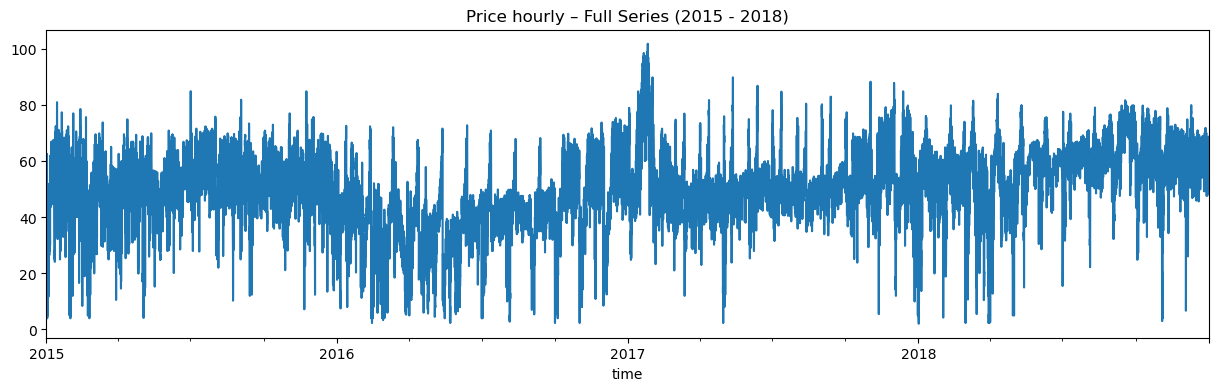

In [5]:
# Full series plot

plt.rcParams["figure.figsize"] = (15,4)

df['price'].plot(title='Price hourly – Full Series (2015 - 2018)')
plt.show()

### Determine if the seasonal component is stationary

### Visual Check

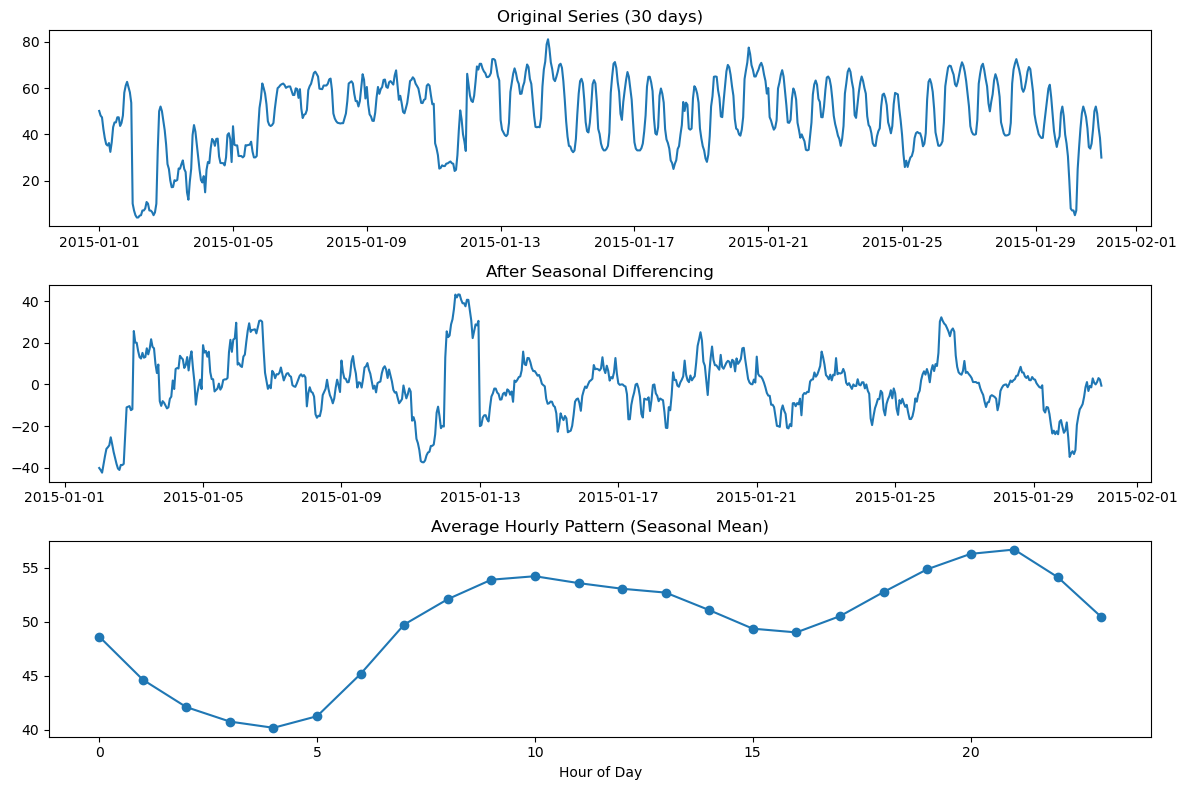

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8))

y = df[['price']]

# Original
axes[0].plot(y[:24*30], label='Original')
axes[0].set_title('Original Series (30 days)')

# Seasonal diff
axes[1].plot(y.diff(24)[:24*30], label='Seasonal Diff (D=1)')
axes[1].set_title('After Seasonal Differencing')

# Seasonal mean by hour
seasonal_mean = y.groupby(y.index.hour).mean()
axes[2].plot(seasonal_mean, marker='o')
axes[2].set_title('Average Hourly Pattern (Seasonal Mean)')
axes[2].set_xlabel('Hour of Day')

plt.tight_layout()
plt.show()

Because **data is hourly**, electricity price almost always has **two seasonalities**:
- daily: 24
- weekly: 168

Let verify.
## Function to make a smoothed (rolling mean window) plot

In [7]:
def smoothed_RollingWindow(window):
    # Set figure size
    plt.rcParams["figure.figsize"] = [14, 5]
    
    # Calculate rolling mean and standard deviation
    rolling_mean = df['price'].rolling(window=window).mean()
    rolling_std = df['price'].rolling(window=window).std()
    
    # Create a plot
    plt.plot(df.index, df['price'], label='Hourly Price', alpha=0.5, color='lightblue')
    plt.plot(rolling_mean.index, rolling_mean, label=f'{window}-Rolling Mean', color='red', linewidth=2)
    plt.fill_between(
        rolling_std.index,
        rolling_mean - rolling_std,
        rolling_mean + rolling_std,
        color='blue',
        alpha=0.2,
        label=f'{window}-Rolling Std Dev'
    )
    
    # Customize the plot
    plt.title(f'Hourly Electricity Price with {window}-rolling mean and standard deviation')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    #plt.grid(True)
    plt.show()


## Smoothed (rolling mean) day plot

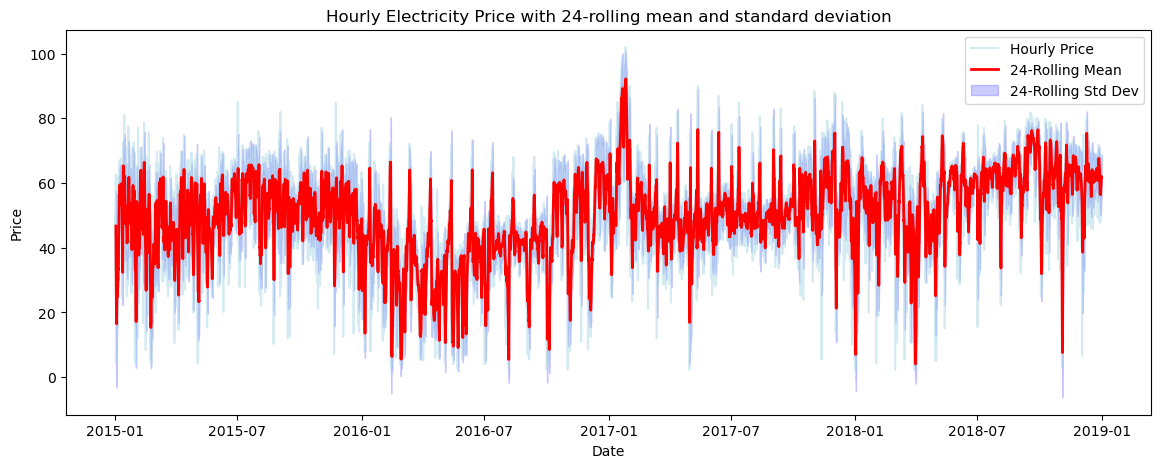

In [8]:
# Rolling mean (24-hour)

window = 24
smoothed_RollingWindow(window)


## Smoothed (rolling mean) week  plot

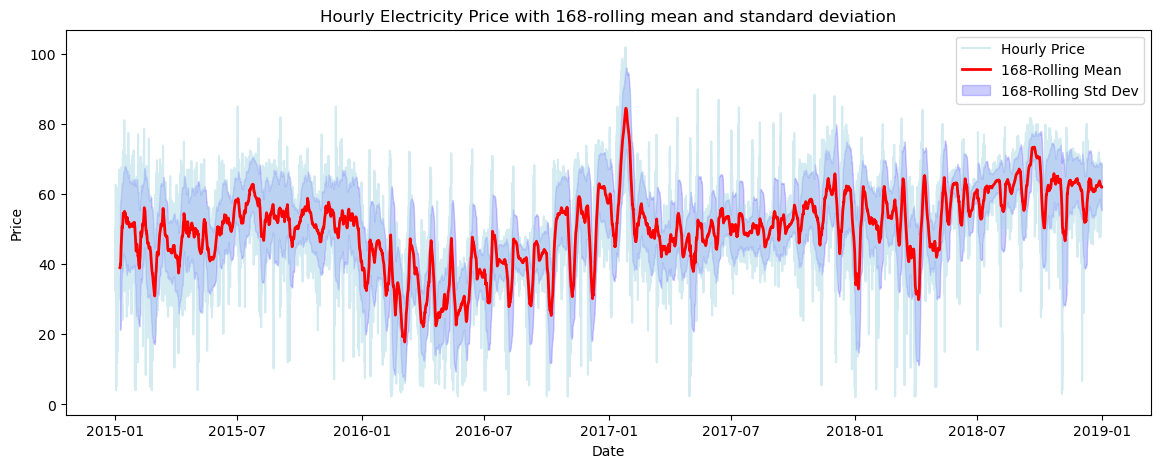

In [9]:
# Rolling mean (168-hour)

window = 168
smoothed_RollingWindow(window)

## Test for stationarity

In [10]:
# Time series stationary

ADF_result = adfuller(df['price'])

print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')        

ADF Statistic: -12.288647154284316
p-value: 7.919257782288071e-23


p-value < 0.05 -> the series behaves as if stationary for modelling purposes 

### Seasonal ADF test via differencing (remove 24-hour seasonality)

In [11]:
#Apply seasonal differencing:
y_seasonal_diff = df['price'].diff(24).dropna()  # s=24 for hourly data

adf_stat, pval, *_ = adfuller(y_seasonal_diff)
print(f"ADF: {adf_stat:.3f}, p-value: {pval:.5f}")


ADF: -28.684, p-value: 0.00000


p-value < 0.05 -> the seasonal-diff behaves as if stationary for modelling purposes. <br>

## ACF/PACF plots

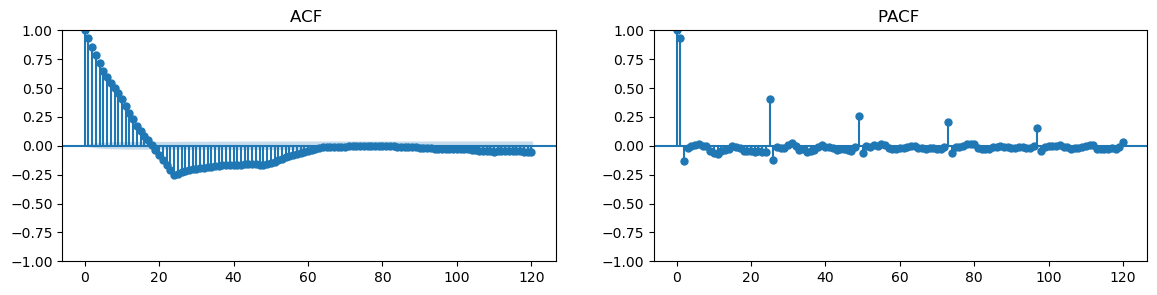

In [12]:
# Autocorrelation function - ACF plot and Partial autocorrelation function - PACF plot

fig, ax = plt.subplots(1,2, figsize=(14,3))
plot_acf(y_seasonal_diff, lags=120, ax=ax[0], title="ACF ")
plot_pacf(y_seasonal_diff, lags=120, ax=ax[1], title="PACF ")
plt.show()

The **ACF plot** of y_seasonal_diff = yₜ − yₜ₋₂₄ shows:
- Very high autocorrelation at small lags (lag 1 close to 1)
- Slow, damped decay, crossing zero and becoming mildly negative
- No explosive behaviour
- No sustained autocorrelation at very large lags

This is a stationary AR behaviour, often AR(1) or AR(2) with a coefficient close to 1.

The **PACF plot** of the same series shows:
- **Very large spike at lag 1**
- **Smaller but still significant spikes at lags 24, 48, 72, …**
- Otherwise near-zero values

This indicates a strong short-term AR component<br>
Remaining weekly dependence (since 168 = 7 × 24, spikes at multiples of 24 after differencing are normal).
This does not imply non-stationarity.

### Compare ACF before and after seasonal differencing

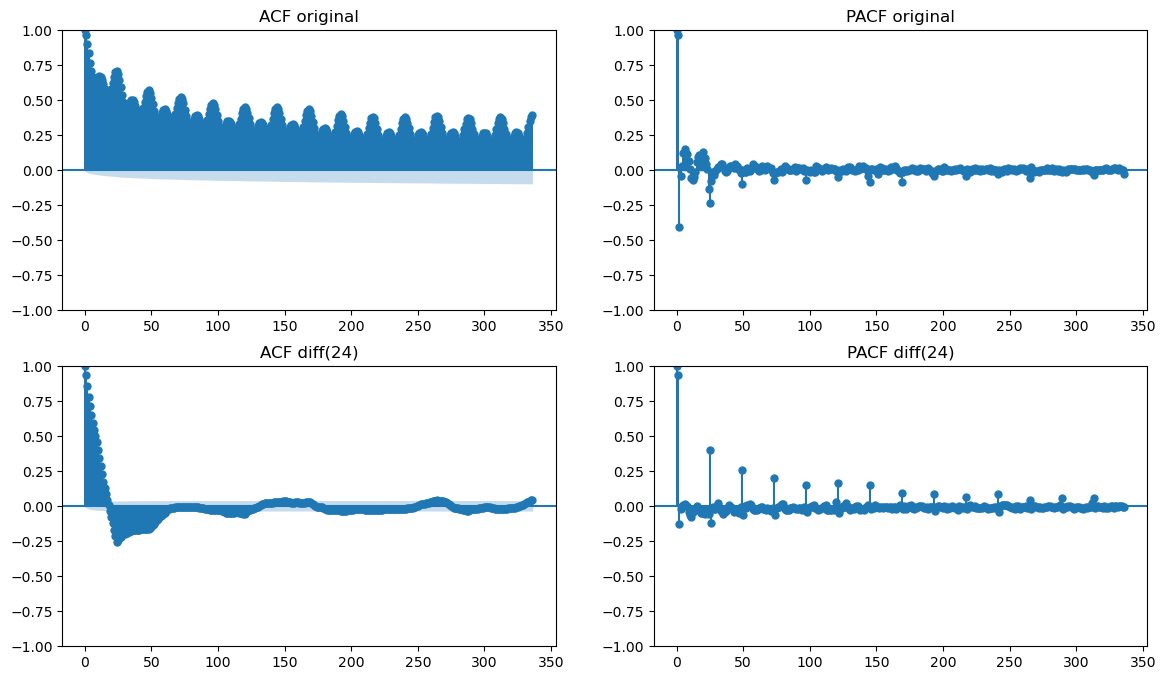

In [28]:
fig, ax = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(df['price'], lags=336, ax=ax[0,0], title="ACF original")
plot_pacf(df['price'], lags=336, ax=ax[0,1], title="PACF original")

plot_acf(y_seasonal_diff, lags=336, ax=ax[1,0], title="ACF diff(24)")
plot_pacf(y_seasonal_diff, lags=336, ax=ax[1,1], title="PACF diff(24)")

plt.show()

The original series exhibits both **daily (period 24) and weekly (period 168) seasonality**. Seasonal differencing with lag 24 removes the daily component, but residual weekly seasonal dependence remains, as evidenced by the ACF at lags 168 and 336.<br>

**Conclusion**:
- ADF statistic: strongly stationary
- ACF: slow decay → AR-type dependence
- PACF: strong lag-1 spike → low-order AR
- Seasonal spikes → seasonal AR structure

So we can conclude the **series is stationary AR** (possibly seasonal AR), not MA

From these plots alone:
- Non-seasonal differencing: **d = 0 (already stationary)**
- Seasonal differencing: **D = 1, s = 24**
- Strong AR behaviour at low lags → p = 1 or 2
- Seasonal AR behaviour → P = 1 likely

So the more adequate model will be a **SARIMA(p, 0, q) × (P, 1, Q)[24]**

## Split data into train and test set

Last year (8760 hours, i.e., 2018 data): This is commonly used in electricity price/demand forecasting literature for multi-year hourly datasets. It allows evaluation over a complete annual cycle, capturing potential longer-term seasonal variations (e.g., summer vs. winter demand patterns influenced by weather, holidays, or economic factors).

In [13]:
# Test set is the last 12 months (1 year) → 365 days to predict: 365x24=8760

horizon = 8760 

train = df[:-horizon]
test = df.iloc[-horizon:] 

# Split target  
y_train = train['price']               
y_test  = test['price']                

# exogenous vars
X_train = train.drop(columns=['price']).copy()    
X_test  = test.drop(columns=['price']).copy()

print(f"Train: {train.shape} Test: {test.shape}")

print('Min train date: ', np.min(train.index), 'Max train date: ', np.max(train.index))
print('Min test date: ', np.min(test.index), 'Max test date: ', np.max(test.index)) 

Train: (26304, 20) Test: (8760, 20)
Min train date:  2015-01-01 00:00:00+01:00 Max train date:  2017-12-31 23:00:00+01:00
Min test date:  2018-01-01 00:00:00+01:00 Max test date:  2018-12-31 23:00:00+01:00


### Function to evaluate the models

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def seasonal_naive_scale(y_train_full, seasonality=24):
    """
    Compute MASE denominator using seasonal naive forecast errors
    on the in-sample training series.
    y_train_full: 1D array-like
    """
    y_train_full = np.asarray(y_train_full).astype(float)
    if len(y_train_full) <= seasonality:
        raise ValueError("Training series too short for MASE seasonality.")
    return np.mean(np.abs(y_train_full[seasonality:] - y_train_full[:-seasonality]))

def mape_calc(y_true, y_pred, eps=1e-6):
    denom = np.maximum(np.abs(y_true), eps)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100    

def model_evaluation(name_model, y_test, y_pred, y_train_full=None):

    y_test = np.asarray(y_test).flatten()
    y_pred = np.asarray(y_pred).flatten()
    
    if y_test.shape != y_pred.shape:
        raise ValueError("y_test and y_pred must have the same shape")
        
    # Standard metrics
    mae_val   = mean_absolute_error(y_test, y_pred)
    rmse_val  = np.sqrt(mean_squared_error(y_test, y_pred))
    mape_val  = mape_calc(y_test, y_pred)
    r2_val    = r2_score(y_test, y_pred)
    
    out = pd.Series({
        'Model': name_model,
        'MAE':   round(mae_val,3),
        'RMSE':  round(rmse_val,3),
        'MAPE':  round(mape_val,3),
        'R2':    round(r2_val,3)
    })
    
    if y_train_full is not None:
        mase_denom = seasonal_naive_scale(y_train_full, seasonality=24)
        out['MASE'] = round(np.mean(np.abs(y_test - y_pred)) / mase_denom, 3)
    else:
        out['MASE'] = np.nan
    
    return out

## Forecasting with a Triple Exponential Smoothing (TETS) model

ETS/TETS models:
- adapt level, trend, and seasonality over time
- assume new observations arrive continuously

Long open-loop ETS forecasts:
- freeze level/trend/seasonality
- become unrealistic over long horizons

So, just like SARIMA 1-year open-loop ETS forecasts are rarely meaningful. <br>
ETS is designed for short- to medium-horizon forecasting with updates, long open-loop forecasts tend to underestimate their performance.

For a fair comparison, with SARIMA models the ETS should be evaluated using a rolling-origin framework. 
However, ETS cannot be reconditioned via state updating, because ETS cannot append new observations without refitting. So we will make a different re-estimation of ETS. 

## Rolling-origin ETS with periodic re-estimation

In [15]:
def seasonal_ets_rolling(y_train, y_test, seasonal_period=24, update_interval=730, trend='add', seasonal='add'):
    """
        - y_train: pd.Series training history (indexed)
        - y_test: pd.Series test set to forecast (indexed, contiguous after y_train)
        - seasonal_period: int seasonal period (e.g., 24 for hourly daily seasonality)
        - update_interval: int number of steps between re-estimations (e.g., 24, 168, 730)
        - trend, seasonal: ETS model options

        Returns
        - y_pred: np.ndarray of length len(y_test) with forecasts
    """
    horizon = len(y_test)
    history = y_train.copy()
    y_pred = np.empty(horizon, dtype=float)

    for start in range(0, horizon, update_interval):
        steps = min(update_interval, horizon - start)

        model = ExponentialSmoothing(history,
                                     seasonal_periods=seasonal_period,
                                     trend=trend,
                                     seasonal=seasonal,
                                     initialization_method='estimated')

        ets_res = model.fit(optimized=True)
        forecast = ets_res.forecast(steps)

        # ensure forecast is aligned as a numpy array
        y_pred[start:start+steps] = np.asarray(forecast)

        # append the observed portion of y_test to history for next refit
        obs_to_append = y_test.iloc[start:start+steps].copy()
        history = pd.concat([history, obs_to_append])

    return y_pred

## Test different rolling periods: day, week, month and year

In [16]:
StartTime = time.time()

periods = [24, 168, 730]
seasons = ['ets_day', 'ets_week', 'ets_month']

pred_cols = {}
res = []
for period, season in zip(periods, seasons):
    y_pred_tets = seasonal_ets_rolling(y_train, y_test, seasonal_period=24, update_interval=period)
    result = model_evaluation(name_model=season,
                              y_test=y_test,
                              y_pred=y_pred_tets,
                              y_train_full=y_train)
    res.append(result)

    # store prediction as a Series aligned with y_test index
    pred_cols[season] = pd.Series(y_pred_tets, index=y_test.index)
    
EndTime = time.time()
print(f"Total time: {round((EndTime-StartTime)/60,1)} min")

resdf = pd.DataFrame(res)

resdf[['Model','MAE','RMSE','MAPE','R2', 'MASE']]

Total time: 26.3 min


,Model,MAE,RMSE,MAPE,R2,MASE
0,ets_day,6.463,9.153,17.878,0.489,0.815
1,ets_week,10.389,14.545,29.915,-0.291,1.310
2,ets_month,12.835,17.581,34.282,-0.887,1.619


## Naive seasonal forecast

In [17]:
def seasonal_naive_forecast(y_train, y_test, season_len=24):
    """
    Forecast each test point using the value from one season ago.
    Assumes hourly data and aligned pandas Series.
    """
    history = pd.concat([y_train, y_test])
    start = len(y_train)
    preds = []

    for i in range(len(y_test)):
        idx = start + i - season_len
        preds.append(history.iloc[idx])

    return np.array(preds)


## Test different seasonal periods: day, week, month and year

In [18]:
periods = [24, 168, 730, 8760]
seasons = ['naive_day', 'naive_week', 'naive_month', 'naive_year']
 
for season_len, season in zip(periods, seasons):
    y_pred_naive = seasonal_naive_forecast(y_train, y_test, season_len)
    result = model_evaluation(name_model=season,
                              y_test=y_test,
                              y_pred=y_pred_naive,
                              y_train_full=y_train)
    res.append(result)

    # store prediction as a Series aligned with y_test index
    pred_cols[season] = pd.Series(y_pred_naive, index=y_test.index)

resdf = pd.DataFrame(res)
resdf.sort_values(by=['Model'], ascending = True, inplace=True)

resdf[['Model','MAE','RMSE','MAPE','R2', 'MASE']]

,Model,MAE,RMSE,MAPE,R2,MASE
0,ets_day,6.463,9.153,17.878,0.489,0.815
2,ets_month,12.835,17.581,34.282,-0.887,1.619
1,ets_week,10.389,14.545,29.915,-0.291,1.310
3,naive_day,7.023,10.454,20.683,0.333,0.886
5,naive_month,11.044,15.094,35.767,-0.391,1.393
4,naive_week,11.184,15.950,33.393,-0.553,1.411
6,naive_year,12.668,15.794,34.753,-0.523,1.598


### Optimize SARIMA parameters with auto_arima

In [16]:
import time 
StartTime = time.time()

import pmdarima as pm
from statsmodels.tsa.statespace.kalman_filter import MEMORY_CONSERVE

# Automatically finds best SARIMA order 
auto_sarima = pm.auto_arima(y_train,
                            seasonal=True, m=24,
                            d=0, D=1,
                            max_p=2, max_q=2, max_P=3, max_Q=3,
                            stepwise=False,                    # ← importante: desativa stepwise para usar todos os núcleos
                            n_jobs=-1,                         # ← USA TODOS OS NÚCLEOS DO CPU
                            trace=True,
                            error_action='ignore',
                            suppress_warnings=True,
                            sarimax_kwargs={'conserve_memory': MEMORY_CONSERVE})

print(f"SARIMAX order/seasonal order: {auto_sarima.order}/{auto_sarima.seasonal_order}")

EndTime = time.time()
print(f"Total time: {round((EndTime-StartTime)/60,1)} min")

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[24] intercept   : AIC=inf, Time=205.24 sec
 ARIMA(0,0,0)(0,1,0)[24] intercept   : AIC=202034.360, Time=2.26 sec
 ARIMA(1,0,0)(1,1,0)[24] intercept   : AIC=141231.688, Time=48.20 sec
 ARIMA(0,0,1)(0,1,1)[24] intercept   : AIC=171232.804, Time=48.17 sec
 ARIMA(0,0,0)(0,1,0)[24]             : AIC=202032.521, Time=0.58 sec
 ARIMA(1,0,0)(0,1,0)[24] intercept   : AIC=146795.569, Time=6.84 sec
 ARIMA(1,0,0)(2,1,0)[24] intercept   : AIC=139078.064, Time=154.20 sec
 ARIMA(1,0,0)(3,1,0)[24] intercept   : AIC=137799.778, Time=351.74 sec
 ARIMA(1,0,0)(3,1,1)[24] intercept   : AIC=inf, Time=683.90 sec
 ARIMA(1,0,0)(2,1,1)[24] intercept   : AIC=inf, Time=285.05 sec
 ARIMA(0,0,0)(3,1,0)[24] intercept   : AIC=197787.696, Time=182.79 sec
 ARIMA(2,0,0)(3,1,0)[24] intercept   : AIC=137062.673, Time=443.60 sec
 ARIMA(2,0,0)(2,1,0)[24] intercept   : AIC=138405.987, Time=204.02 sec
 ARIMA(2,0,0)(3,1,1)[24] intercept   : AIC=inf, Time=894.50 sec

## Forecast electricity price with the SARIMA model for the last 12 months — year 2018

SARIMA models are optimized for **short-horizon forecasting**. When evaluated on very long horizons without reconditioning, simple seasonal naïve models often outperform them, especially in electricity price forecasting. So, to forecast the entire 2018 year SARIMA should be used in a **rolling_origin framework** where the model is reconditioned using observed values at regular intervals, for example, at **every 24 hours** or **every week**. 

We will reconditione the model **every month** because of computational constraints.

## Rolling SARIMAX with periodic re-estimation

In [12]:
def rolling_sarimax_refit_rolling_window(y_train, y_test, order, seasonal_order, exog_train=None, exog_test=None,
                                         update_interval=730,         # ~monthly
                                         train_window=8760,           # cap history (e.g., last 1 year)
                                         maxiter=30,
                                         method="lbfgs",
                                         simple_differencing=True,
                                         concentrate_scale=True):
    """
    Period refits but using a FIXED-LENGTH rolling training window to avoid MemoryError.
    Fits SARIMAX on the last `train_window` hours of available history, forecasts next block,
    then appends observed test values and repeats.

    Works for SARIMA (no exog) and SARIMAX (with exog).
    """

    y_train = pd.Series(y_train).copy()
    y_test = pd.Series(y_test).copy()
    n_test = len(y_test)

    if exog_train is not None:
        exog_train = pd.DataFrame(exog_train).copy()
    if exog_test is not None:
        exog_test = pd.DataFrame(exog_test).copy()

    preds = np.empty(n_test, dtype=float)

    # history starts as train
    hist_y = y_train.copy()
    hist_exog = exog_train.copy() if exog_train is not None else None

    previous_params = None
    update_interval = int(max(1, update_interval))

    for start in range(0, n_test, update_interval):
        steps = min(update_interval, n_test - start)

        # ---- rolling training slice (cap memory) ----
        y_fit = hist_y.iloc[-train_window:] if len(hist_y) > train_window else hist_y

        if hist_exog is not None:
            exog_fit = hist_exog.loc[y_fit.index]  # align by index
        else:
            exog_fit = None

        model = SARIMAX(
            y_fit,
            exog=exog_fit,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False,
            simple_differencing=simple_differencing,
            concentrate_scale=concentrate_scale
        )

        fit_kwargs = dict(disp=False, maxiter=maxiter, method=method)

        # Warm-start if parameter sizes match
        if previous_params is not None:
            try:
                fit_kwargs["start_params"] = previous_params
            except Exception:
                pass

        # low_memory exists in many statsmodels versions; try it safely
        try:
            fit_kwargs["low_memory"] = True
        except Exception:
            pass

        res = model.fit(**fit_kwargs)

        # ---- forecast next block ----
        if exog_test is not None:
            exog_fc = exog_test.iloc[start:start + steps]
        else:
            exog_fc = None

        fc = res.forecast(steps=steps, exog=exog_fc)
        preds[start:start + steps] = np.asarray(fc)

        # ---- append observed test to history (for next refit) ----
        y_obs = y_test.iloc[start:start + steps]
        hist_y = pd.concat([hist_y, y_obs])

        if exog_test is not None:
            exog_obs = exog_test.iloc[start:start + steps]
            hist_exog = pd.concat([hist_exog, exog_obs]) if hist_exog is not None else exog_obs.copy()

        previous_params = res.params.copy()

    return preds

## Test different rolling periods: day, week, month and year

In [13]:
StartTime = time.time()

order = (2,0,0)
seasonal_order = (3,1,0,24)

periods = [24, 168, 730]
seasons = ['sarima_day', 'sarima_week', 'sarima_month']

for period, season in zip(periods, seasons):
    y_pred_sarima = rolling_sarimax_refit_rolling_window(y_train=y_train, y_test=y_test, order=order, seasonal_order=seasonal_order,
                                                          update_interval=period,    
                                                          train_window=8760,         # last 1 year only
                                                          exog_train=None,
                                                          exog_test=None,
                                                          maxiter=30)
    
    result = model_evaluation(season, y_test, y_pred_sarima, y_train_full, seasonal_period= 24, use_seasonal_naive=True)
    res.append(result)

    # store prediction as a Series aligned with y_test index
    pred_cols[season] = pd.Series(y_pred_sarima, index=y_test.index)

EndTime = time.time()
print(f"Total time: {round((EndTime-StartTime)/60,1)} min")

resdf = pd.DataFrame(res)
resdf.sort_values(by=['Model'], ascending = True, inplace=True)

styled_resdf = resdf[['Model','MAE','RMSE','MAPE','R2','MASE']].style.format({
    'Model': str,
    'mae': '{:.1f}',
    'rmse': '{:.1f}',
    'mape': '{:.1f}%',
    'r2': '{:.1f}%'
})

styled_resdf

Total time: 110.5 min


,Model,MAE,RMSE,MAPE,R2,MASE
0,ets_day,6.463073,9.152902,17.878401,0.488666,0.815174
2,ets_month,12.834777,17.580908,34.281591,-0.886557,1.618824
1,ets_week,10.389187,14.545260,29.915015,-0.291309,1.310366
3,naive_day,7.023009,10.454207,20.683336,0.332933,0.885797
5,naive_month,11.043518,15.094339,35.766793,-0.390642,1.392896
4,naive_week,11.184500,15.949865,33.393402,-0.552749,1.410678
6,naive_year,12.667951,15.793744,34.753231,-0.522500,1.597782
7,sarima_day,57.407035,59.165963,101.901321,-20.366388,7.240629
9,sarima_month,57.332590,58.762976,100.376909,-20.076321,7.231239
8,sarima_week,57.098308,58.616766,99.993178,-19.971570,7.201690


## Forecasting with exogeneous variables 

SARIMAX is a low-dimensional parametric model. It is mandatory to perform feature selection to include a small, well-chosen subset of variables, that have physical meaning, strong independent signal and low collinearity. Those are:
- typically calendar terms (sin/cos) 
- total_load_actual
- gen_fossil_hard_coal
- gen_fossil_gas
- gen_hydro_pumped_storage_consumption
- gen_other_renewable
- gen_wind_onshore


In [14]:
# Derive and Select exogenous variables

df['hour_sin']  = np.sin(2*np.pi*df.index.hour/24)
df['hour_cos']  = np.cos(2*np.pi*df.index.hour/24)

horizon = 8760 

train = df[:-horizon]
test = df.iloc[-horizon:] 

# Split target  
y_train = train['price']               
y_test  = test['price']                

# exogenous vars
X_train = train.drop('price', axis=1)
X_test  = test.drop('price', axis=1)

print(f"Train: {X_train.shape} Test: {X_test.shape}")

# Scale all variables except sin/cos
from sklearn.preprocessing import StandardScaler

cols_to_scale = ['total_load_actual',
                 'gen_wind_onshore',
                 'gen_solar',
                 'gen_fossil_gas',
                 'gen_hydro_pumped_storage_consumption',
                 'humidity',
                 'temperature']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])


Train: (26304, 21) Test: (8760, 21)


Exogenous variables were standardized to improve numerical stability, while the target variable (electricity price) was kept in its 
original scale to preserve interpretability and correct likelihood-based inference.

StandardScaler (z-score) is the right choice because:
- centers variables (mean = 0)
- scales by variability (std = 1)
- is robust to changes in range
- improves numerical conditioning
- keeps likelihood well behaved

And importantly:
- does not distort temporal structure
-  nicely with rolling re-estimation

### Re-optimise SARIMAX parameters with auto_arima

In [20]:
# Automatically finds best SARIMAX order WITH exog
 
StartTime = time.time()

# Automatically finds best SARIMA order 
auto_sarimax = pm.auto_arima(y_train,
                             X=X_train_scaled,
                             seasonal=True, m=24,
                             d=0, D=1,
                             max_p=2, max_q=2, max_P=3, max_Q=3,
                             stepwise=False,                    # ← importante: desativa stepwise para usar todos os núcleos
                             n_jobs=-1,                         # ← USA TODOS OS NÚCLEOS DO CPU
                             trace=True,
                             error_action='ignore',
                             suppress_warnings=True,
                             sarimax_kwargs={'conserve_memory': MEMORY_CONSERVE})

print(f"SARIMAX order/seasonal order: {auto_sarimax.order}/{auto_sarimax.seasonal_order}")

EndTime = time.time()
print(f"Total time: {round((EndTime-StartTime)/60,1)} min")

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[24] intercept   : AIC=inf, Time=546.63 sec
 ARIMA(0,0,0)(0,1,0)[24] intercept   : AIC=193260.226, Time=12.89 sec
 ARIMA(1,0,0)(1,1,0)[24] intercept   : AIC=135953.735, Time=183.65 sec
 ARIMA(0,0,1)(0,1,1)[24] intercept   : AIC=164643.074, Time=195.70 sec
 ARIMA(0,0,0)(0,1,0)[24]             : AIC=193258.468, Time=26.59 sec
 ARIMA(1,0,0)(0,1,0)[24] intercept   : AIC=142396.544, Time=29.18 sec
 ARIMA(1,0,0)(2,1,0)[24] intercept   : AIC=133903.553, Time=560.72 sec
 ARIMA(1,0,0)(3,1,0)[24] intercept   : AIC=132335.074, Time=1008.16 sec
 ARIMA(1,0,0)(3,1,1)[24] intercept   : AIC=inf, Time=1536.78 sec
 ARIMA(1,0,0)(2,1,1)[24] intercept   : AIC=inf, Time=675.95 sec
 ARIMA(0,0,0)(3,1,0)[24] intercept   : AIC=189469.801, Time=648.45 sec
 ARIMA(2,0,0)(3,1,0)[24] intercept   : AIC=132221.933, Time=1335.90 sec
 ARIMA(2,0,0)(2,1,0)[24] intercept   : AIC=133796.313, Time=633.49 sec
 ARIMA(2,0,0)(3,1,1)[24] intercept   : AIC=inf, Time=18

### Monthly Rolling Forecast: to predict the entire year 

In [20]:
# How many rows contain any NaN?
print("Rows with any NaN in X_train_scaled:", X_train_scaled.isna().any(axis=1).sum())
print("Rows with any NaN in X_test_scaled:", X_test_scaled.isna().any(axis=1).sum())

# Drop rows with NaNs in X (and also protect against NaNs in y)
mask_train = ~(X_train_scaled.isna().any(axis=1) | y_train.isna())
X_train_scaled = X_train_scaled.loc[mask_train]
y_train = y_train.loc[mask_train]

mask_test = ~(X_test_scaled.isna().any(axis=1) | y_test.isna())
X_test_scaled = X_test_scaled.loc[mask_test]
y_test = y_test.loc[mask_test]

print(f"X_train_scaled, y_train after cleaning: {X_train_scaled.shape}, {y_train.shape}")
print(f"X_test_scaled, y_test after cleaning: {X_test_scaled.shape}, {y_test.shape}")

Rows with any NaN in X_train_scaled: 44
Rows with any NaN in X_test_scaled: 2
X_train_scaled, y_train after cleaning: (26260, 21), (26260,)
X_test_scaled, y_test after cleaning: (8758, 21), (8758,)


In [21]:
StartTime = time.time()

order = (1,0,1)
seasonal_order = (3,1,0,24)
seasonal_period = 24

periods = [168, 730]
seasons = ['sarimax_week', 'sarimax_month']

for period, season in zip(periods, seasons):
    y_pred_sarimax = rolling_sarimax_refit_rolling_window(y_train=y_train,
                                                         y_test=y_test,
                                                         order=order,
                                                         seasonal_order=seasonal_order,
                                                         update_interval=period,
                                                         train_window=8760,
                                                         exog_train=X_train_scaled,
                                                         exog_test=X_test_scaled,
                                                         maxiter=30)
    
    result = model_evaluation(season, y_test, y_pred_sarimax, y_train_full, seasonal_period= 24, use_seasonal_naive=True)
    res.append(result)

    # store prediction as a Series aligned with y_test index
    pred_cols[season] = pd.Series(y_pred_sarimax, index=y_test.index)

EndTime = time.time()
print(f"Total time: {round((EndTime-StartTime)/60,1)} min")

resdf = pd.DataFrame(res)
resdf.sort_values(by=['Model'], ascending = True, inplace=True)

resdf

Total time: 810.2 min


,Model,MAE,RMSE,MAPE,R2,MASE
0,ets_day,6.463073,9.152902,17.878401,0.488666,0.815174
2,ets_month,12.834777,17.580908,34.281591,-0.886557,1.618824
1,ets_week,10.389187,14.545260,29.915015,-0.291309,1.310366
3,naive_day,7.023009,10.454207,20.683336,0.332933,0.885797
5,naive_month,11.043518,15.094339,35.766793,-0.390642,1.392896
4,naive_week,11.184500,15.949865,33.393402,-0.552749,1.410678
6,naive_year,12.667951,15.793744,34.753231,-0.522500,1.597782
7,sarima_day,57.407035,59.165963,101.901321,-20.366388,7.240629
9,sarima_month,57.332590,58.762976,100.376909,-20.076321,7.231239
8,sarima_week,57.098308,58.616766,99.993178,-19.971570,7.201690


Rolling SARIMAX with exogenous variables at hourly scale is not **computationally feasible**.<br>
The above SARIMAX setup is extremely expensive:
- Hourly data, 8760 forecasts
- Seasonal period 24
- Seasonal differencing D = 1
- Exogenous regressors (8 variables)
- Rolling refits every month (12 times)

During rolling forecasting each refit involves:
- Kalman filtering
- State-space optimization
- Re-estimation of regression coefficients
With exogenous variables, this is O(T³) in practice

Due to the high computational cost of rolling refits in SARIMAX models with hourly exogenous variables, forecasts were generated using a fixed model estimated on the training period and applied dynamically to the test year.

The worse results of SARIMAX are explained by dynamic forecasting over all of 2018. Static SARIMAX + dynamic long-horizon forecasting often collapses. 
SARIMAX is computationally infeasible with rolling refits. SARIMAX is not designed to compete with ML in high-dimensional hourly EPF. Therefore SARIMAX was developed as a classical statistical reference, not as a competitive model.

## Plot the two best models: ets_day and the naive_day model

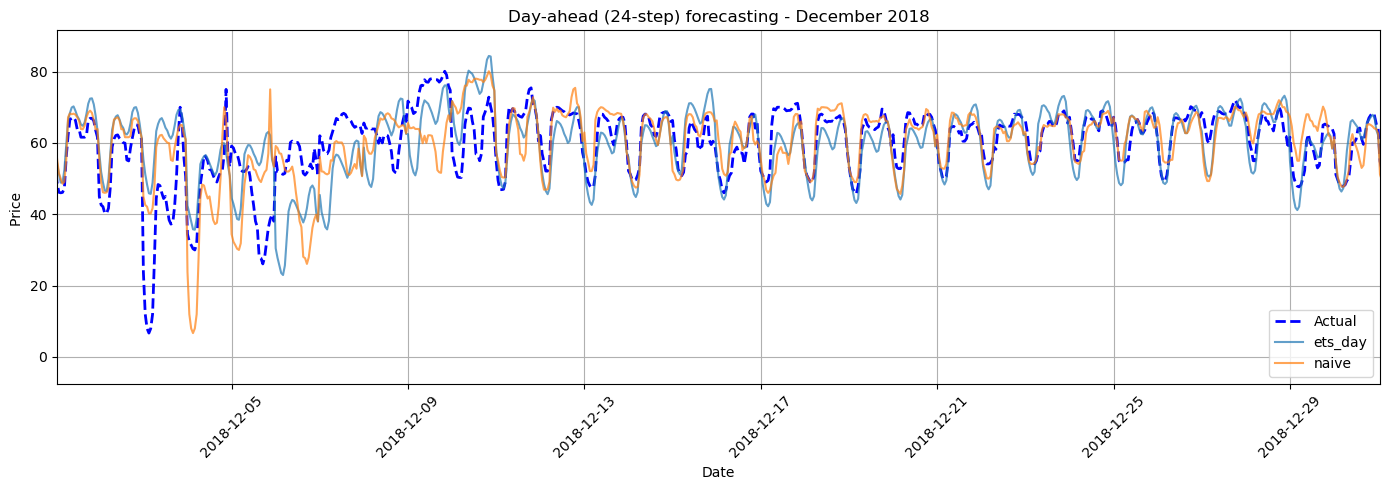

In [19]:
pred_df = pd.DataFrame(pred_cols)
 
# === 9. Plot ===
plt.figure(figsize=(14, 5))
plt.plot(test.index, y_test, label='Actual', color='blue', linestyle='--', linewidth=2)
plt.plot(test.index, pred_df['ets_day'], label='ets_day', alpha=0.7)
plt.plot(test.index, pred_df['naive_day'], label='naive', alpha=0.7)
plt.xlim(pd.to_datetime(['2018-12-01', '2018-12-31']))  # Zoom
plt.title('Day-ahead (24-step) forecasting - December 2018')
plt.xlabel('Date'); plt.ylabel('Price ')
plt.legend(); plt.grid(True); plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

In [24]:
# Save the two best 2018 statistical predictions to make stacking ensemble

pred_df[['ets_day','naive_day']].to_csv("stats_preds2018.csv", index=False)
np.save("dates_stat2018.npy", X_test.index)


## Train ETS_day and Naive_day on 2015-2016 and get 2017 predictions<br> to make a Ridge/ElasticNet stacking Ensemble
### Split data: Sliding expanding-window CV

| Window | Train     | Test |
|--------|-----------|------|
| 1      | 2015–2016 | 2017 |

This is a **expanding window cross-validation**, chronologically consistent, with no look-ahead bias, and realistic for operational forecasting.<br>
An expanding-window cross-validation strategy was adopted to preserve the temporal structure of the data and avoid look-ahead bias.

In [21]:
df.insert(0, 'year', df.index.year)  

train_years = [2015, 2016]
test_year =  2017
        
train_df = df[df['year'].isin(train_years)]
test_df = df[df['year'] == test_year]
 
# Split target  
y_train = train_df['price'].copy()               
y_test  = test_df['price'].copy()                

print(f"Train: {y_train.shape} Test: {y_test.shape}")

print('Min train date: ', np.min(y_train.index), 'Max train date: ', np.max(y_train.index))
print('Min test date: ', np.min(y_test.index), 'Max test date: ', np.max(y_test.index)) 

Train: (17544,) Test: (8760,)
Min train date:  2015-01-01 00:00:00+01:00 Max train date:  2016-12-31 23:00:00+01:00
Min test date:  2017-01-01 00:00:00+01:00 Max test date:  2017-12-31 23:00:00+01:00


In [22]:
StartTime = time.time()

y_pred_tets2017 = seasonal_ets_rolling(y_train, y_test, seasonal_period=24, update_interval=24)

result = model_evaluation(name_model='ETS_day',
                          y_test=y_test,
                          y_pred=y_pred_tets2017,
                          y_train_full=y_train)

EndTime = time.time() 
print(f"Total time: {round((EndTime-StartTime)/60,1)} min")

# store prediction in a dataframe aligned with y_test index
stats_preds = pd.DataFrame({'ETS_day': y_pred_tets2017}, index=y_test.index)

res=[]
res.append(result)
result_df = pd.DataFrame(res)
result_df[['Model','MAE','RMSE','MAPE','R2','MASE']]

Total time: 17.5 min


,Model,MAE,RMSE,MAPE,R2,MASE
0,ETS_day,7.026,9.352,15.914,0.42,0.852


In [23]:
season_len=24

y_pred_naive2017 = seasonal_naive_forecast(y_train, y_test, season_len)
 
result = model_evaluation(name_model='Naive_day',
                              y_test=y_test,
                              y_pred=y_pred_naive2017,
                              y_train_full=y_train)
# store predictions in the dataframe
stats_preds['Naive_day'] = y_pred_naive2017

res=[]
res.append(result)
resdf = pd.DataFrame(res)

# Concatenate all DataFrames into a single DataFrame
result_df = pd.concat([result_df, resdf], ignore_index=True)      

result_df.sort_values(by=['RMSE'], ascending = True, inplace=True)
result_df[['Model','MAE','RMSE','MAPE','R2', 'MASE']]
print(result_df)

       Model    MAE    RMSE    MAPE    R2   MASE
0    ETS_day  7.026   9.352  15.914  0.42  0.852
1  Naive_day  7.297  10.844  16.741  0.22  0.885


In [25]:
# Save 2017 predictions to make stacking ensemble

stats_preds.to_csv("stats_preds2017.csv", index=False)
np.save("dates_stat2017.npy", y_test.index)